<a href="https://colab.research.google.com/github/miguelmorandini/am-t4-s1a2026/blob/main/MultiNeuralCensus0606.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Pipeline Random Forest [Census Base]

### Importar dados do Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Bibliotecas de Python

In [24]:
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix

### Carregar Diggest de base_census

In [25]:
with open('/content/drive/MyDrive/DSM/5º Semestre - 2026/aprendizagem-de-maquina/amt4/census.pkt', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [26]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [27]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

In [29]:
random_census = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)

random_census.fit(X_census_treinamento, Y_census_treinamento)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0, warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, random_state=0)

### Criando base previsora

In [ ]:
previsores_random = random_census.predict(X_census_teste)

In [30]:
accuracy_score(Y_census_teste, previsores_random)

0.8507676560900717

In [31]:
confusion_matrix(Y_census_teste, previsores_random)

array([[3420,  273],
       [ 456,  736]])

0.8507676560900717

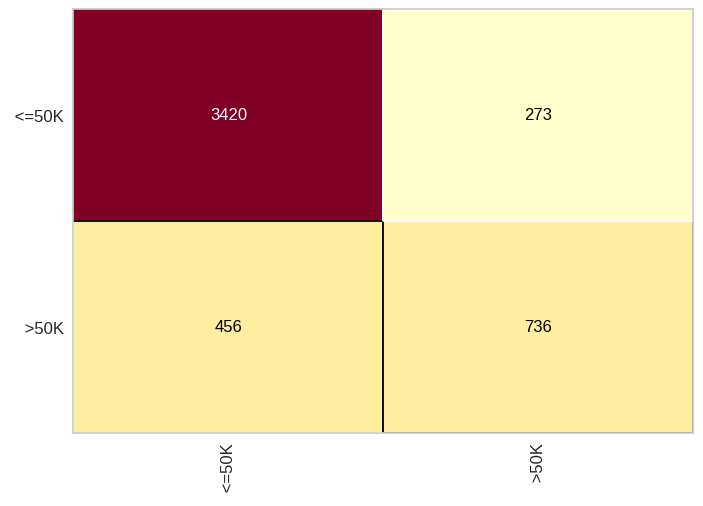

In [33]:
cm_census = ConfusionMatrix(random_census)
cm_census.fit(X_census_treinamento, Y_census_treinamento)
cm_census.score(X_census_teste, Y_census_teste)


In [34]:
print(classification_report(Y_census_teste, previsores_random))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.62      0.67      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.79      4885
weighted avg       0.85      0.85      0.85      4885



## Pipeline Regressão | Digest [Census Base]

In [35]:
from sklearn.linear_model import LogisticRegression

In [36]:
regressao_census = LogisticRegression(random_state=1)

regressao_census.fit(X_census_treinamento, Y_census_treinamento)

LogisticRegression(random_state=1)

In [37]:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=1, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', random_state=1)

In [38]:
regression_previsores = regressao_census.predict(X_census_teste)
regression_previsores

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [39]:
accuracy_score(Y_census_teste, regression_previsores)

0.8497441146366428

0.8497441146366428

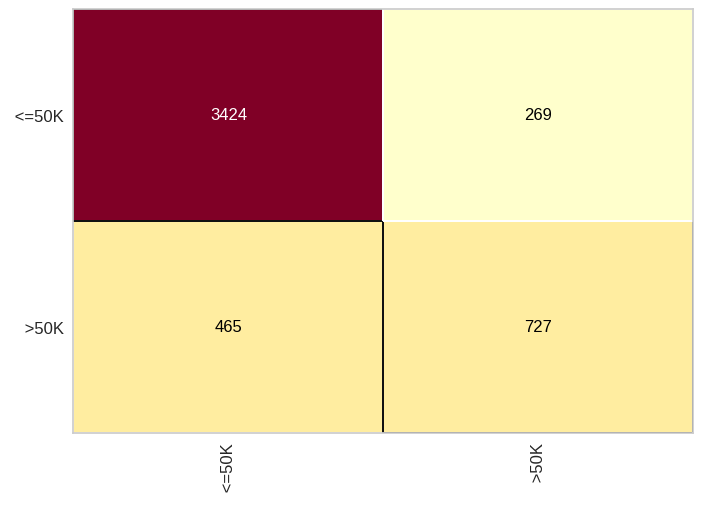

In [40]:
cm_regressao = ConfusionMatrix(regressao_census)
cm_regressao.fit(X_census_treinamento, Y_census_treinamento)
cm_regressao.score(X_census_teste, Y_census_teste)

In [41]:
print(classification_report(Y_census_teste, regression_previsores))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      3693
        >50K       0.73      0.61      0.66      1192

    accuracy                           0.85      4885
   macro avg       0.81      0.77      0.78      4885
weighted avg       0.84      0.85      0.84      4885

